In [1]:
from scipy.special import logsumexp
from scipy.stats import poisson
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib widget

KeyboardInterrupt: 

In [ ]:

class PoissonHMM:
    
    def __init__(self, A, B, pi):
        '''
        Initialize the HMM with the transition matrix (A), emission probability matrix (B) and prior probability distribution (pi)
        '''
        self.A = np.array(A)
        self.log_A = np.log(A)

        self.B = np.array(B)

        self.pi = np.array(pi)
        self.log_pi = np.log(self.pi)

        self.N = self.A.shape[0]

        self.obs = None
        self.T = 0

        self.log_emissions = None

        self.eps = 1e-12


    def generate_samples(self, Nsamples):
        '''generate a random markov chain from the transition matrix A and sample obervations from each hidden state'''

        # initialize the hidden states
        hidden_states = np.zeros(Nsamples, dtype=int)
        hidden_states[0] = np.random.choice(self.N, p = self.pi)

        # initialize the obervations
        obervations = np.zeros((Nsamples, self.B.shape[1]))
        obervations[0] = np.random.poisson(lam = self.B[hidden_states[0]])

        for t in range(1, Nsamples):
            hidden_states[t] = np.random.choice(self.N, p=self.A[hidden_states[t-1]])
            obervations[t] = np.random.poisson(lam = self.B[hidden_states[t]])

        return hidden_states, obervations


    def compute_emissions(self):
        '''compute the emission probabilities of the observations given the emission probability matrix (B)'''

        self.log_emissions_by_dim = poisson.logpmf(
            self.obs[:, None, :],
            self.B[None, :, :]
        )

        self.log_emissions = self.log_emissions_by_dim.sum(axis=2)

    
    def set_observations(self, obs):

        self.obs = np.asarray(obs)
        self.T = len(obs)

        self.compute_emissions()
    

    def forward_probability(self):
        '''
        computes the logarithm of the forward probabilities (alpha) of the observations given the hmm
        '''

        # initialize the forward probabilities
        log_alpha = np.zeros((self.T, self.N))
        log_alpha[0] = (
            self.log_pi
            + self.log_emissions[0]
        )

        # run recursion to solve the rest
        for t in range(1, self.T):

            # compute the next forward probability
            log_alpha[t] = (
                logsumexp(
                    log_alpha[t-1][:,None]
                    + self.log_A, axis = 0
                )
                + self.log_emissions[t]
            )

        return log_alpha
    
    
    def backward_probability(self):
        '''
        compute the logarithm of the backward probabilities (beta) of the observations given the hmm
        '''

        # initialize the backward probabilities
        log_beta = np.zeros((self.T, self.N))
        log_beta[-1] = 0.0 # log(1) = n0

        for t in range(self.T - 2, -1, -1):
            
            # compute the previous backward probability
            log_beta[t] = logsumexp(
                self.log_emissions[t + 1][None, :]
                + self.log_A
                + log_beta[t + 1][None, :],
                axis = 1
            ) 
        
        return log_beta
    

    def viterbi(self):
        '''
        using the viterbi algorithm in log-space to find the latent variables which maximize the probability of the emission sequence
        '''

        # initialize the viterbi and the backpointers
        log_viterbi = np.zeros((self.T, self.N))
        backpointers = np.zeros((self.T, self.N), dtype=int)

        log_viterbi[0] = (
            self.log_pi 
            + self.log_emissions[0]
        )
        

        # run the recursion 
        for t in range(1, self.T):
            log_values = np.array(
                log_viterbi[t - 1][:, None]
                + self.log_A
            )
            
            log_viterbi[t] = np.max(log_values, axis = 0) + self.log_emissions[t]
            backpointers[t] = np.argmax(log_values, axis = 0)

        # inbitialize the most likely states
        states = np.zeros(self.T, dtype = int)
        states[-1] = np.argmax(log_viterbi[-1])

        # loop backwards over time and use the backpointers to find the most likely state sequence
        for t in range(self.T - 1, 0, -1):
            states[t - 1] = backpointers[t, states[t]]

        return states
    

    def compute_log_xi(self, log_alpha, log_beta):

        log_likelihood = logsumexp(log_alpha[-1])  # scalar

        log_xi = (
            log_alpha[:-1, :, None]          # (T-1) x N x 1
            + self.log_A[None, :, :]         # 1 x N x N
            + self.log_emissions[1:, None, :] # (T-1) x 1 x N
            + log_beta[1:, None, :]          # (T-1) x 1 x N
            - log_likelihood
        )

        return log_xi # (T-1) x N x N


    def compute_log_gamma(self, log_alpha, log_beta):
        
        log_likelihood = logsumexp(log_alpha[-1]) # scalar

        log_gamma = (
            log_alpha       # T x N
            + log_beta      # T x N
            - log_likelihood
        )

        return log_gamma # T x N
    

    def forward_backward(self, transition_update_mask = None):
        '''using the forward backward algorithm to update the transition matrix (A) and the emissions matrix (B) using the forward and backwards probabilities'''

        #---------------------------Expectation----------------------------------

        # compute the forward and reverse probabilities
        self.log_alpha = self.forward_probability()   # T x N
        self.log_beta = self.backward_probability()   # T x N


        # compuite xi
        log_xi = self.compute_log_xi(self.log_alpha, self.log_beta) # (T-1) x N x N

        # compute gamma
        log_gamma = self.compute_log_gamma(self.log_alpha, self.log_beta) # T x N



        #---------------------------Maximization---------------------------------

        # numerator
        log_sum_xi_over_time = logsumexp(log_xi, axis = 0)      # N x N

        # denominator
        log_sum_xi_over_states_and_time = logsumexp(
            log_sum_xi_over_time,
            axis = 1
        )     # N

        log_A_hat = (
            log_sum_xi_over_time[:, :]  # N x N
            - log_sum_xi_over_states_and_time[:, None]
        )

        A_hat = np.exp(log_A_hat)

        
        # Optionally freeze some elements of the transition matrix
        if transition_update_mask is not None:

            # True = update
            # False = freeze

            A_new = self.A.copy()

            for i in range(self.N):

                update_mask = transition_update_mask[i]
                freeze_mask = ~update_mask

                # keep frozen entries
                frozen_mass = self.A[i, freeze_mask].sum()

                remaining_mass = 1.0 - frozen_mass

                if remaining_mass < 0:
                    raise ValueError("Frozen probabilities exceed 1.")

                if update_mask.sum() > 0:

                    # proposed updated values
                    updated_vals = A_hat[i, update_mask]

                    # renormalize only the updated entries
                    updated_vals = (
                        updated_vals
                        / updated_vals.sum()
                        * remaining_mass
                    )

                    A_new[i, update_mask] = updated_vals

            A_hat = A_new


        gamma = np.exp(log_gamma)
        B_hat = (
            gamma.T @ self.obs
            / gamma.sum(axis=0)[:, None]
        ) # N x D

            
        return A_hat, B_hat
    

    def fit_em(self, Niters):
        '''fit the transition and emissions matrices using expectation maximization'''

        llhs = np.zeros(Niters + 1)
        llhs[0] = logsumexp(self.forward_probability()[-1])
        for iter in range(Niters):

            # run the forward backwards pass
            A_hat, B_hat = self.forward_backward()

            # update the matrices
            self.A = A_hat
            self.log_A = np.log(self.A + self.eps)
            self.B = B_hat

            # recompute the emissions
            self.compute_emissions()

            log_alpha = self.forward_probability()

            # compute the log-likelihood
            llhs[iter + 1] = logsumexp(log_alpha[-1])

        return llhs




Transtion matrix A:
[[0.7 0.1 0.2]
 [0.3 0.6 0.1]
 [0.1 0.2 0.7]]

Emissions matrix B:
[[  1   3]
 [ 10  13]
 [100 113]]

initial probability distribution pi:
[0.3 0.4 0.3]



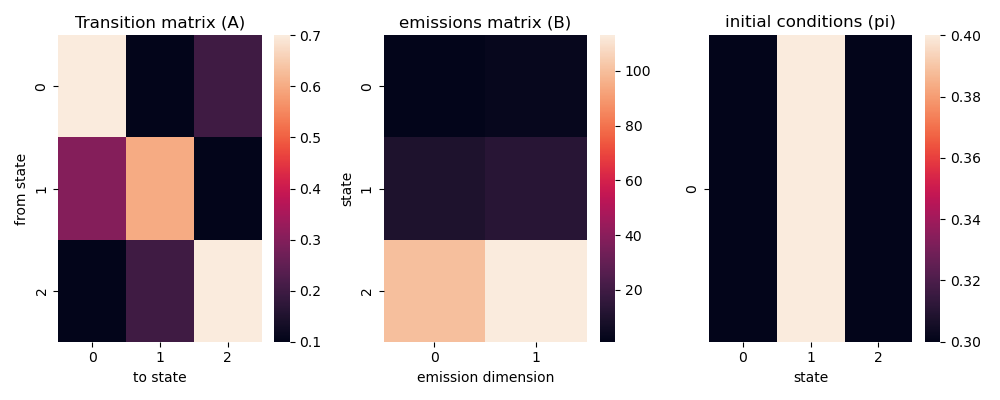

In [153]:
A = np.array(
    [
        [0.7, 0.1, 0.2],
        [0.3, 0.6, 0.1],
        [0.1, 0.2, 0.7]
    ]
)

B = np.array(
    [
        [1,3],
        [10,13],
        [100,113]
    ]
)

pi = np.array(
    [0.3, 0.4, 0.3]
)

print(f"Transtion matrix A:\n{A}\n")
print(f'Emissions matrix B:\n{B}\n')
print(f'initial probability distribution pi:\n{pi}\n')
              
def plot_hmm(A, B, pi):
    fig, axs = plt.subplots(1, 3, figsize = (10, 4))
    sns.heatmap(A, ax = axs[0])
    axs[0].set_title('Transition matrix (A)')
    axs[0].set_ylabel('from state')
    axs[0].set_xlabel('to state')
    sns.heatmap(B, ax = axs[1])
    axs[1].set_title("emissions matrix (B)")
    axs[1].set_ylabel('state')
    axs[1].set_xlabel('emission dimension')
    sns.heatmap([pi], ax = axs[2])
    axs[2].set_title('initial conditions (pi)')
    axs[2].set_ylabel('')
    axs[2].set_xlabel('state')
    plt.tight_layout()
    plt.show()

plot_hmm(A, B, pi)




(2000,) (2000, 2)
estimated emissions: [array([1.01468625, 2.92256342]), array([10.00359066, 12.78096948]), array([100.43227666, 113.27521614])]


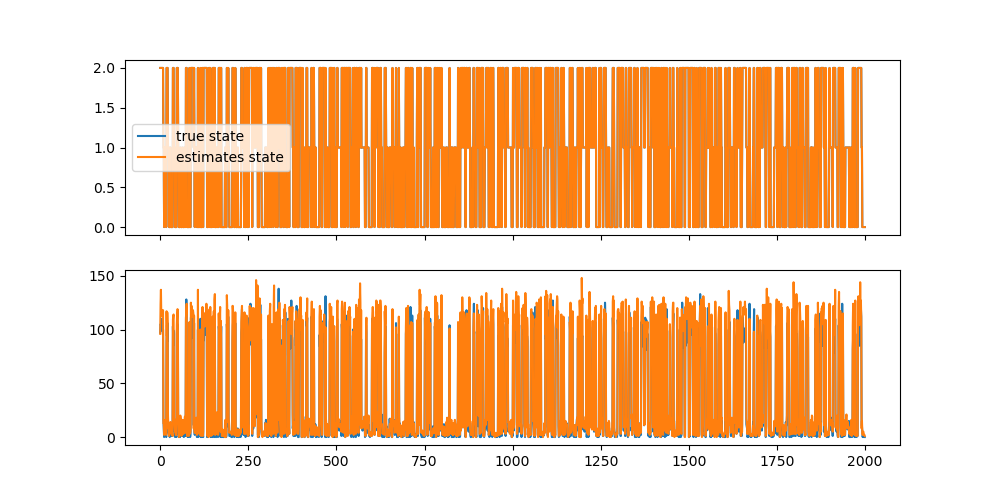

In [157]:


# initialize the hmm
hmm = PoissonHMM(A, B, pi)

# generate some samples
hidden_states, observations = hmm.generate_samples(Nsamples=2000)
print(hidden_states.shape, observations.shape)

# estimate the mean for each state
mean_obervations = [np.mean(observations[hidden_states == i, :], axis = 0) for i in range(A.shape[0])]
print(f'estimated emissions: {mean_obervations}')


# set the obervation into the hmm
hmm.set_observations(observations)

# run the viterbi to recover the state sequence
states = hmm.viterbi()



fig, axs = plt.subplots(2, 1, sharex = True, figsize = (10, 5))
axs[0].plot(hidden_states, label = 'true state')
axs[0].plot(states, label = 'estimates state')
axs[0].legend()
axs[1].plot(observations)
plt.show()

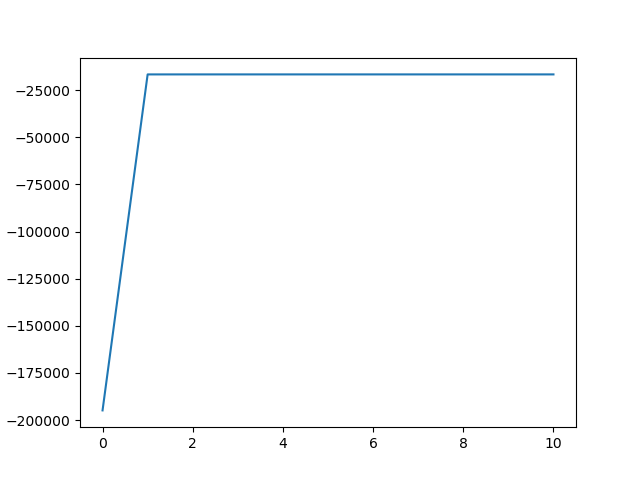

In [158]:
N = 3
D = 2

initial_A = np.random.dirichlet(np.ones(N), size=N)

initial_B = np.random.uniform(
    low=0.5,
    high=200,
    size=(N,D)
)

initial_pi = np.ones(N) / N


new_hmm = PoissonHMM(initial_A, initial_B, initial_pi)
new_hmm.set_observations(observations)
llhs = new_hmm.fit_em(Niters = 10)

plt.figure()
plt.plot(llhs)
plt.show()


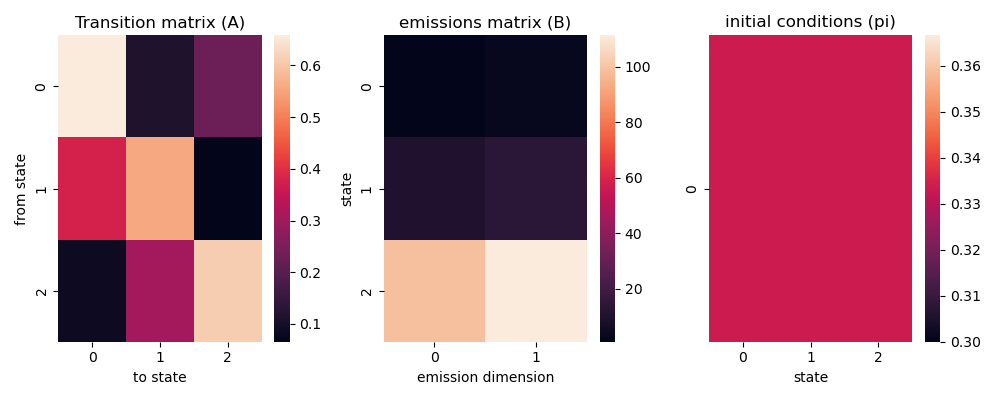

In [156]:
plot_hmm(new_hmm.A, new_hmm.B, new_hmm.pi)